In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', None)

print("All libraries loaded successfully")

All libraries loaded successfully


In [7]:
df = pd.read_csv('data/raw/Fraud_Data.csv')
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (151112, 11)

First 5 rows:


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


In [9]:
print("=== DATA TYPES ===")
print(df.dtypes)
print("\n=== MISSING VALUES ===")
print(df.isnull().sum())
print("\n=== DUPLICATES ===")
print("Duplicate rows:", df.duplicated().sum())

=== DATA TYPES ===
user_id             int64
signup_time           str
purchase_time         str
purchase_value      int64
device_id             str
source                str
browser               str
sex                   str
age                 int64
ip_address        float64
class               int64
dtype: object

=== MISSING VALUES ===
user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64

=== DUPLICATES ===
Duplicate rows: 0


In [10]:
print("=== BASIC STATISTICS ===")
df.describe()

=== BASIC STATISTICS ===


,user_id,purchase_value,age,ip_address,class
count,151112.000000,151112.000000,151112.000000,1.511120e+05,151112.000000
mean,200171.040970,36.935372,33.140704,2.152145e+09,0.093646
std,115369.285024,18.322762,8.617733,1.248497e+09,0.291336
min,2.000000,9.000000,18.000000,5.209350e+04,0.000000
25%,100642.500000,22.000000,27.000000,1.085934e+09,0.000000
50%,199958.000000,35.000000,33.000000,2.154770e+09,0.000000
75%,300054.000000,49.000000,39.000000,3.243258e+09,0.000000
max,400000.000000,154.000000,76.000000,4.294850e+09,1.000000


=== CLASS DISTRIBUTION ===
Legitimate (0): 136,961 (90.64%)
Fraud (1):      14,151 (9.36%)


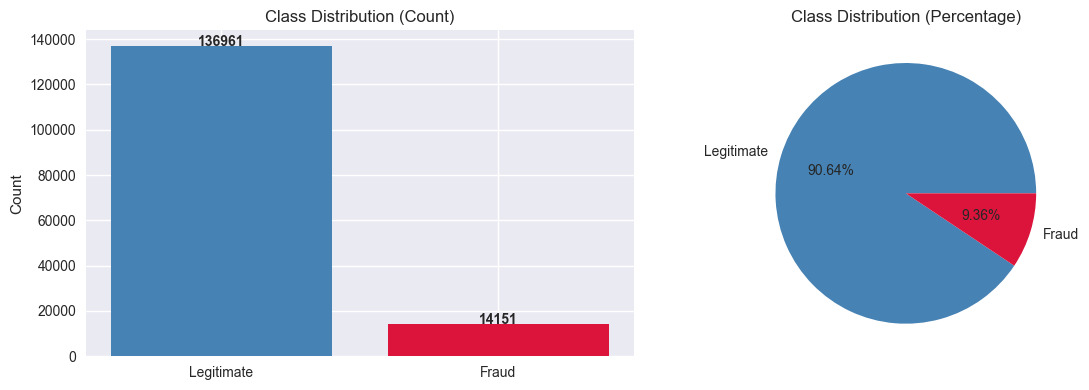

In [11]:
fraud_counts = df['class'].value_counts()
fraud_pct = df['class'].value_counts(normalize=True) * 100

print("=== CLASS DISTRIBUTION ===")
print(f"Legitimate (0): {fraud_counts[0]:,} ({fraud_pct[0]:.2f}%)")
print(f"Fraud (1):      {fraud_counts[1]:,} ({fraud_pct[1]:.2f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Legitimate', 'Fraud'], fraud_counts.values, color=['steelblue', 'crimson'])
axes[0].set_title('Class Distribution (Count)')
axes[0].set_ylabel('Count')
for i, v in enumerate(fraud_counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

axes[1].pie(fraud_counts.values, labels=['Legitimate', 'Fraud'],
            autopct='%1.2f%%', colors=['steelblue', 'crimson'])
axes[1].set_title('Class Distribution (Percentage)')

plt.tight_layout()
plt.savefig('data/processed/class_distribution_fraud.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
df['signup_time'] = pd.to_datetime(df['signup_time'])
df['purchase_time'] = pd.to_datetime(df['purchase_time'])
print("Datetime columns fixed")
print(df[['signup_time', 'purchase_time']].dtypes)

Datetime columns fixed
signup_time      datetime64[us]
purchase_time    datetime64[us]
dtype: object


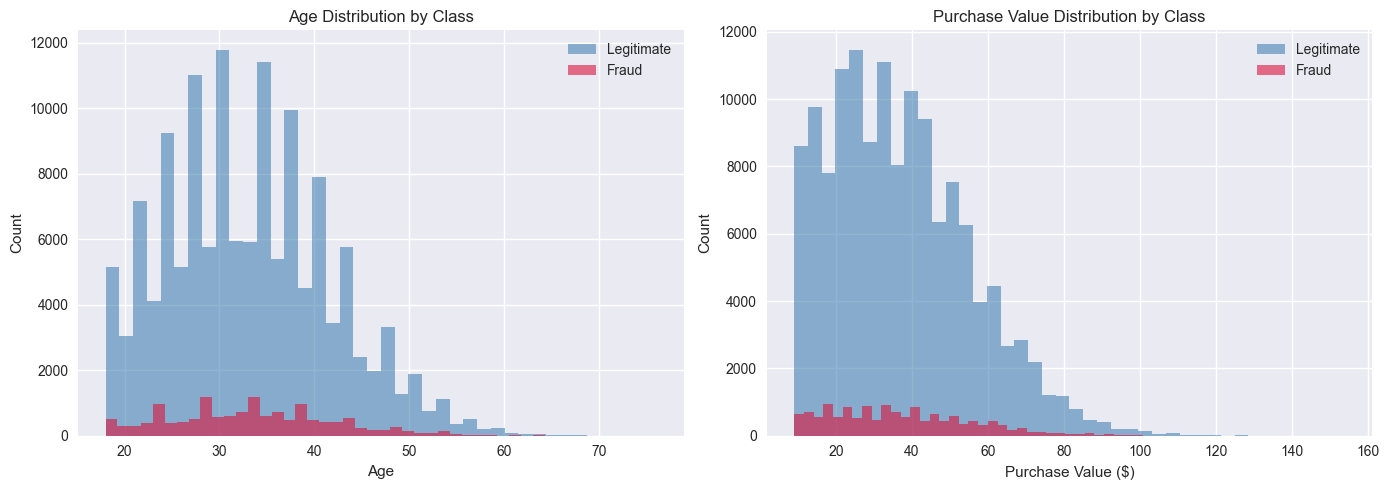

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df[df['class']==0]['age'], bins=40, alpha=0.6, color='steelblue', label='Legitimate')
axes[0].hist(df[df['class']==1]['age'], bins=40, alpha=0.6, color='crimson', label='Fraud')
axes[0].set_title('Age Distribution by Class')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].hist(df[df['class']==0]['purchase_value'], bins=40, alpha=0.6, color='steelblue', label='Legitimate')
axes[1].hist(df[df['class']==1]['purchase_value'], bins=40, alpha=0.6, color='crimson', label='Fraud')
axes[1].set_title('Purchase Value Distribution by Class')
axes[1].set_xlabel('Purchase Value ($)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('data/processed/distributions_fraud.png', dpi=150, bbox_inches='tight')
plt.show()

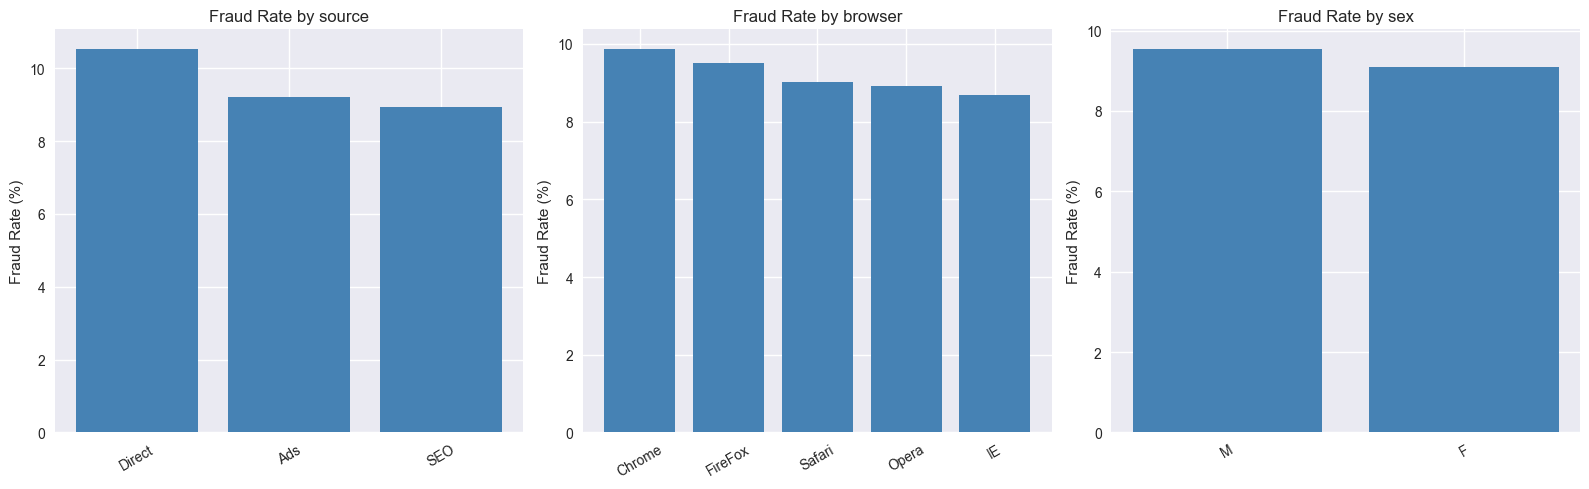

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, ['source', 'browser', 'sex']):
    fraud_rate = df.groupby(col)['class'].mean().sort_values(ascending=False)
    ax.bar(fraud_rate.index, fraud_rate.values * 100, color='steelblue')
    ax.set_title(f'Fraud Rate by {col}')
    ax.set_ylabel('Fraud Rate (%)')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('data/processed/categorical_fraud_rates.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
def ip_to_int(ip):
    try:
        parts = str(ip).split('.')
        return int(parts[0]) * 16777216 + int(parts[1]) * 65536 + int(parts[2]) * 256 + int(parts[3])
    except:
        return 0

df['ip_int'] = df['ip_address'].apply(ip_to_int)
print("IP to integer conversion done")
print(df[['ip_address', 'ip_int']].head())

IP to integer conversion done
     ip_address  ip_int
0  7.327584e+08       0
1  3.503114e+08       0
2  2.621474e+09       0
3  3.840542e+09       0
4  4.155831e+08       0


In [16]:
ip_df = pd.read_csv('data/raw/IpAddress_to_Country.csv')
print("IP country data shape:", ip_df.shape)
ip_df.head()

IP country data shape: (138846, 3)


,lower_bound_ip_address,upper_bound_ip_address,country
0,16777216.0,16777471,Australia
1,16777472.0,16777727,China
2,16777728.0,16778239,China
3,16778240.0,16779263,Australia
4,16779264.0,16781311,China


In [18]:
ip_df_sorted = ip_df.sort_values('lower_bound_ip_address').reset_index(drop=True)
ip_df_sorted['lower_bound_ip_address'] = ip_df_sorted['lower_bound_ip_address'].astype('int64')
ip_df_sorted['upper_bound_ip_address'] = ip_df_sorted['upper_bound_ip_address'].astype('int64')

df_sorted = df.sort_values('ip_int').reset_index(drop=True)
df_sorted['ip_int'] = df_sorted['ip_int'].astype('int64')

merged = pd.merge_asof(
    df_sorted,
    ip_df_sorted[['lower_bound_ip_address', 'upper_bound_ip_address', 'country']],
    left_on='ip_int',
    right_on='lower_bound_ip_address',
    direction='backward'
)

merged['country'] = merged.apply(
    lambda x: x['country'] if x['ip_int'] <= x['upper_bound_ip_address'] else 'Unknown',
    axis=1
)

print("Merge done. Shape:", merged.shape)
print("Sample countries:", merged['country'].value_counts().head(10))

Merge done. Shape: (151112, 15)
Sample countries: country
Unknown    151112
Name: count, dtype: int64


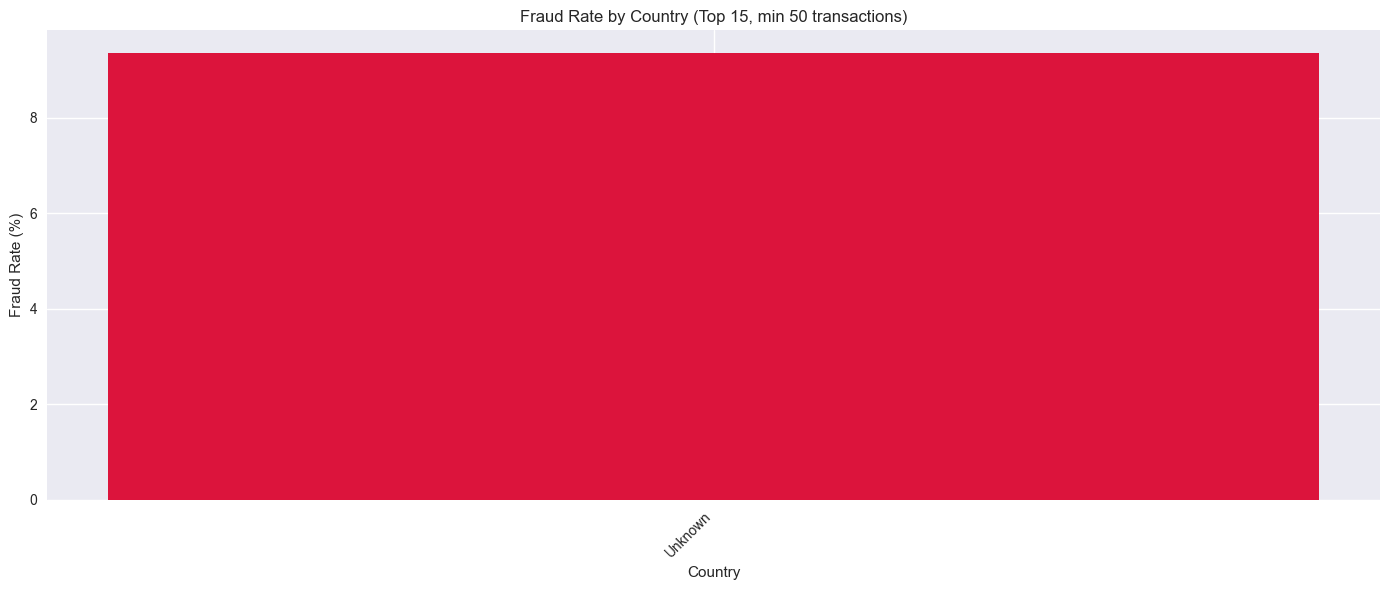

In [19]:
country_fraud = merged.groupby('country').agg(
    total=('class', 'count'),
    fraud=('class', 'sum')
).reset_index()
country_fraud['fraud_rate'] = country_fraud['fraud'] / country_fraud['total'] * 100
country_fraud = country_fraud[country_fraud['total'] > 50].sort_values('fraud_rate', ascending=False).head(15)

plt.figure(figsize=(14, 6))
plt.bar(country_fraud['country'], country_fraud['fraud_rate'], color='crimson')
plt.title('Fraud Rate by Country (Top 15, min 50 transactions)')
plt.xlabel('Country')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('data/processed/fraud_by_country.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
merged.to_csv('data/processed/fraud_data_with_country.csv', index=False)
print("Saved to data/processed/fraud_data_with_country.csv")
print("Final shape:", merged.shape)

Saved to data/processed/fraud_data_with_country.csv
Final shape: (151112, 15)
